# Question: How has housing affordability changed across major U.S. cities from 2015–2024 after accounting for CPI and mortgage rates, and which cities are most resilient to macroeconomic pressures?

**Introduction**

Urban housing affordability is becoming an increasingly important economic and social issue across major U.S. cities. Housing prices and rent have increased in recent years; however, nominal increases alone do not fully explain affordability trends. Inflation and changing mortgage interest rates influence household purchasing power and cost of home ownership. This project will analyze housing affordability trends from 2015-2024 across 10 selected major U.S. cities by integrating select U.S. census economic and housing data with city-level Consumer Price Index (CPI) measures, city-level mortgage delinquencies, and national mortgage rate data. We will evaluate if income growth has kept pace with rising housing expenses and how affordability outcomes have changed over time.

**Target Audience**

We beleve our analysis can benefit several groups of people:

*   Young professionals choosing a city: This group needs clear insights into which destinations offer the best housing affordability. Affordability goes past nominal prices and incomes, and is affected by less-obvious factors such as inflation, interest rates, and local economic conditions.
*   State, city, and local politicians and their staffs: Leaders require data-driven evidence on affordability and the pressures it exerts on their constituents. This analysis could be particularly useful because it goes beyond nominal figures, and because it compares across cities, so leaders can truly compare their city to others and identify whether they are succeeding or struggling in managing affordabiltiy and overall attractiveness.




In [1]:
import requests
import json
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.linear_model import LinearRegression  
import statsmodels.api as sm
from math import sqrt 
from sklearn.metrics import mean_squared_error

## STEP 1a: Use the Census API to download historical data from 2015-2024 on 10 major U.S. cities for our analysis

In [2]:
# List of the 10 cities we would like to examine for our EDA
cities_of_interest = [
    "New York city, New York",
    "Boston city, Massachusetts",
    "Philadelphia city, Pennsylvania",
    "Chicago city, Illinois",
    "Dallas city, Texas",
    "Los Angeles city, California",
    "San Francisco city, California",
    "Atlanta city, Georgia",
    "Houston city, Texas",
    "Seattle city, Washington"]

# We are excluding 2020 because census data was unavailable due to COVID-19 impacts. We discovered when originally trying to run for 2017-2024
years = [2015, 2016, 2017, 2018, 2019, 2021, 2022, 2023, 2024]

city_variables = ",".join([
    "NAME",
    "B01003_001E",   # Total population
    "B01002_001E",   # Median age
    "B25077_001E",   # Median home value
    "B25058_001E",   # Median contract rent (your original rent)
    "B25064_001E",   # Median gross rent
    "B19013_001E",   # Median household income
    "B19301_001E",   # Per capita income
    "B23025_005E",   # Unemployment count
    # Housing cost burden
    "B25070_001E",
    "B25070_007E",
    "B25070_008E",
    "B25070_009E",
    "B25070_010E",
    # Educational attainment
    "B15003_001E",
    "B15003_022E",
    "B15003_023E",
    "B15003_024E",
    "B15003_025E"
])

# Create empty DataFrame
df_city_econ_data = pd.DataFrame()

# Loop through each year
for year in years:

    url = f"https://api.census.gov/data/{year}/acs/acs1"

    params = {
        "get": city_variables,
        "for": "place:*",
        "in": "state:*"
    }

    response = requests.get(url, params=params)

    data = response.json()
    columns = data[0]
    rows = data[1:]

    df_year = pd.DataFrame(rows, columns=columns)

    # Keep only cities of interest
    df_year = df_year[df_year["NAME"].isin(cities_of_interest)].copy()

    df_year["year"] = year

    # Convert numeric columns
    numeric_cols = [
        "B01003_001E","B01002_001E","B25077_001E",
        "B25058_001E","B25064_001E",
        "B19013_001E","B19301_001E","B23025_005E",
        "B25070_001E","B25070_007E","B25070_008E",
        "B25070_009E","B25070_010E",
        "B15003_001E","B15003_022E","B15003_023E",
        "B15003_024E","B15003_025E"
    ]

    for col in numeric_cols:
        df_year[col] = pd.to_numeric(df_year[col], errors="coerce")

    # Housing cost burden (% households spending ≥30% income on housing)
    df_year["housing_cost_burden_pct"] = (
        df_year[
            ["B25070_007E","B25070_008E",
             "B25070_009E","B25070_010E"]
        ].sum(axis=1)
        / df_year["B25070_001E"]
    )

    # Educational attainment (% Bachelor's or higher)
    df_year["pct_bachelors_plus"] = (
        df_year[
            ["B15003_022E","B15003_023E",
             "B15003_024E","B15003_025E"]
        ].sum(axis=1)
        / df_year["B15003_001E"]
    )

    # ---------------------------
    # Rename columns
    # ---------------------------
    df_year.rename(columns={
        "NAME": "city",
        "B01003_001E": "total_population",
        "B01002_001E": "median_age",
        "B25077_001E": "median_home_value",
        "B25058_001E": "median_contract_rent",
        "B25064_001E": "median_gross_rent",
        "B19013_001E": "median_household_income",
        "B19301_001E": "per_capita_income",
        "B23025_005E": "unemployment_count"
    }, inplace=True)

    # Clean city names
    df_year["city"] = (
        df_year["city"]
        .str.replace(r"\scity,.*", "", regex=True)
        .str.strip()
    )

    # Drop unused raw columns
    df_year.drop(columns=[
        "state","place",
        "B25070_001E","B25070_007E","B25070_008E",
        "B25070_009E","B25070_010E",
        "B15003_001E","B15003_022E","B15003_023E",
        "B15003_024E","B15003_025E"
    ], inplace=True)

    # Append to master dataframe
    df_city_econ_data = pd.concat(
        [df_city_econ_data, df_year],
        ignore_index=True
    )

print(df_city_econ_data)

            city  total_population  median_age  median_home_value  \
0        Atlanta            463875        33.8             241200   
1        Chicago           2720556        34.2             238500   
2         Boston            669469        31.8             453000   
3       New York           8550405        36.0             538300   
4    Los Angeles           3971896        35.0             542100   
..           ...               ...         ...                ...   
85      New York           8478072        38.5             778600   
86  Philadelphia           1573916        35.7             253600   
87        Dallas           1326093        33.2             340400   
88       Houston           2387910        34.0             301200   
89       Seattle            780992        35.4             950800   

    median_contract_rent  median_gross_rent  median_household_income  \
0                    809                981                    50210   
1                    864   

In [3]:
df_city_econ_data.head(10)

,city,total_population,median_age,median_home_value,median_contract_rent,median_gross_rent,median_household_income,per_capita_income,unemployment_count,year,housing_cost_burden_pct,pct_bachelors_plus
0,Atlanta,463875,33.8,241200,809,981,50210,39660,18694,2015,0.461207,0.483028
1,Chicago,2720556,34.2,238500,864,985,50702,31641,137758,2015,0.477752,0.366433
2,Boston,669469,31.8,453000,1277,1423,58263,37842,26201,2015,0.512652,0.466290
3,New York,8550405,36.0,538300,1199,1317,55752,34396,329222,2015,0.507147,0.368444
4,Los Angeles,3971896,35.0,542100,1161,1271,52024,30136,153135,2015,0.578819,0.326421
5,San Francisco,864816,38.3,941400,1609,1659,92094,57917,27235,2015,0.375258,0.551561
6,Philadelphia,1567442,34.1,150700,777,952,41233,23961,83008,2015,0.519494,0.273993
7,Dallas,1300082,32.6,152400,756,903,45918,30569,34773,2015,0.450593,0.317542
8,Houston,2298628,32.6,152200,783,923,48064,29310,71115,2015,0.479418,0.308607
9,Seattle,684443,35.5,530900,1259,1356,80349,50290,20976,2015,0.425948,0.620965


## STEP 1b: Join our additional datasets (CPI Data, Mortgage Default Rates, Interest Rates) to our DataFrame

### Merging the by-city CPI data

In [4]:
df_cpi = pd.read_csv('city_cpi.csv')

df_cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       90 non-null     str    
 1   year       90 non-null     int64  
 2   cpi_index  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


In [5]:
df_econ_cpi = pd.merge(df_city_econ_data,df_cpi, on = ['city','year'], how = 'inner')

df_econ_cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     90 non-null     str    
 1   total_population         90 non-null     int64  
 2   median_age               90 non-null     float64
 3   median_home_value        90 non-null     int64  
 4   median_contract_rent     90 non-null     int64  
 5   median_gross_rent        90 non-null     int64  
 6   median_household_income  90 non-null     int64  
 7   per_capita_income        90 non-null     int64  
 8   unemployment_count       90 non-null     int64  
 9   year                     90 non-null     int64  
 10  housing_cost_burden_pct  90 non-null     float64
 11  pct_bachelors_plus       90 non-null     float64
 12  cpi_index                90 non-null     float64
dtypes: float64(4), int64(8), str(1)
memory usage: 10.0 KB


### Merging the by-city Mortgage Default Rate Data

In [6]:
df_mortgage = pd.read_csv('mortgage_delinquency.csv')

df_mortgage.info()

<class 'pandas.DataFrame'>
RangeIndex: 91 entries, 0 to 90
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   city                  90 non-null     str    
 1   year                  90 non-null     float64
 2   mortgage_delinquency  90 non-null     float64
dtypes: float64(2), str(1)
memory usage: 3.0 KB


In [7]:
df_econ_cpi_mortgage = pd.merge(df_econ_cpi,df_mortgage, on = ['city','year'], how = 'inner')

df_econ_cpi_mortgage.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     90 non-null     str    
 1   total_population         90 non-null     int64  
 2   median_age               90 non-null     float64
 3   median_home_value        90 non-null     int64  
 4   median_contract_rent     90 non-null     int64  
 5   median_gross_rent        90 non-null     int64  
 6   median_household_income  90 non-null     int64  
 7   per_capita_income        90 non-null     int64  
 8   unemployment_count       90 non-null     int64  
 9   year                     90 non-null     int64  
 10  housing_cost_burden_pct  90 non-null     float64
 11  pct_bachelors_plus       90 non-null     float64
 12  cpi_index                90 non-null     float64
 13  mortgage_delinquency     90 non-null     float64
dtypes: float64(5), int64(8), str(1)
memory 

### Merging the national Mortgage Interest Rate data

In [8]:
df_rates = pd.read_csv('interest_rates.csv')

df_rates.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   city            90 non-null     str    
 1   year            90 non-null     int64  
 2   interest_rates  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


In [9]:
df_combined_data = pd.merge(df_econ_cpi_mortgage,df_rates, on = ['city','year'], how = 'inner')

df_combined_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     90 non-null     str    
 1   total_population         90 non-null     int64  
 2   median_age               90 non-null     float64
 3   median_home_value        90 non-null     int64  
 4   median_contract_rent     90 non-null     int64  
 5   median_gross_rent        90 non-null     int64  
 6   median_household_income  90 non-null     int64  
 7   per_capita_income        90 non-null     int64  
 8   unemployment_count       90 non-null     int64  
 9   year                     90 non-null     int64  
 10  housing_cost_burden_pct  90 non-null     float64
 11  pct_bachelors_plus       90 non-null     float64
 12  cpi_index                90 non-null     float64
 13  mortgage_delinquency     90 non-null     float64
 14  interest_rates           90 non-null   

## STEP 2: Take our data from "wide" to "long" and begin checks for data quality

In [10]:
df_combined_data.head(10)

,city,total_population,median_age,median_home_value,median_contract_rent,median_gross_rent,median_household_income,per_capita_income,unemployment_count,year,housing_cost_burden_pct,pct_bachelors_plus,cpi_index,mortgage_delinquency,interest_rates
0,Atlanta,463875,33.8,241200,809,981,50210,39660,18694,2015,0.461207,0.483028,220.048,2.908,3.85
1,Chicago,2720556,34.2,238500,864,985,50702,31641,137758,2015,0.477752,0.366433,227.343,1.975,3.85
2,Boston,669469,31.8,453000,1277,1423,58263,37842,26201,2015,0.512652,0.466290,256.376,1.717,3.85
3,New York,8550405,36.0,538300,1199,1317,55752,34396,329222,2015,0.507147,0.368444,258.376,2.183,3.85
4,Los Angeles,3971896,35.0,542100,1161,1271,52024,30136,153135,2015,0.578819,0.326421,239.724,1.542,3.85
5,San Francisco,864816,38.3,941400,1609,1659,92094,57917,27235,2015,0.375258,0.551561,254.910,0.917,3.85
6,Philadelphia,1567442,34.1,150700,777,952,41233,23961,83008,2015,0.519494,0.273993,243.609,2.967,3.85
7,Dallas,1300082,32.6,152400,756,903,45918,30569,34773,2015,0.450593,0.317542,217.375,2.708,3.85
8,Houston,2298628,32.6,152200,783,923,48064,29310,71115,2015,0.479418,0.308607,211.926,2.850,3.85
9,Seattle,684443,35.5,530900,1259,1356,80349,50290,20976,2015,0.425948,0.620965,245.496,1.083,3.85


In [11]:
df_combined_data_long = pd.melt(

    df_combined_data, id_vars=['city', 'year'],  # Columns to keep
    var_name='statistic',  # New column for variable names
    value_name='value')  # New column for values

df_combined_data_long

,city,year,statistic,value
0,Atlanta,2015,total_population,463875.00
1,Chicago,2015,total_population,2720556.00
2,Boston,2015,total_population,669469.00
3,New York,2015,total_population,8550405.00
4,Los Angeles,2015,total_population,3971896.00
...,...,...,...,...
1165,New York,2024,interest_rates,6.72
1166,Philadelphia,2024,interest_rates,6.72
1167,Dallas,2024,interest_rates,6.72
1168,Houston,2024,interest_rates,6.72


In [12]:
df_combined_data_long.info()

# Data type validation & checking for NULLs

<class 'pandas.DataFrame'>
RangeIndex: 1170 entries, 0 to 1169
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       1170 non-null   str    
 1   year       1170 non-null   int64  
 2   statistic  1170 non-null   str    
 3   value      1170 non-null   float64
dtypes: float64(1), int64(1), str(2)
memory usage: 66.2 KB


After running .info() on our data, we see that we have no NaN values and our City/Year/Statistic/Value columns are all set to the correct data type

In [13]:
df_combined_data.describe() # Ensure reasonable / sensical ranges for our measurement columns

,total_population,median_age,median_home_value,median_contract_rent,median_gross_rent,median_household_income,per_capita_income,unemployment_count,year,housing_cost_burden_pct,pct_bachelors_plus,cpi_index,mortgage_delinquency,interest_rates
count,9.000000e+01,90.000000,9.000000e+01,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000,90.000000
mean,2.302309e+06,35.170000,5.290089e+05,1335.988889,1467.455556,72756.788889,47200.811111,83324.377778,2019.444444,0.473625,0.451335,269.224244,1.529944,4.644444
std,2.303990e+06,2.088355,3.259576e+05,389.523145,373.839092,23436.827441,16349.117733,90238.973698,3.039482,0.053291,0.117943,34.110337,0.768038,1.292773
min,4.638750e+05,31.800000,1.507000e+05,756.000000,903.000000,39759.000000,23961.000000,13801.000000,2015.000000,0.312719,0.273993,211.926000,0.292000,2.960000
25%,7.460285e+05,33.425000,2.541750e+05,982.250000,1129.500000,55373.750000,35193.750000,20999.250000,2017.000000,0.445667,0.359581,243.778250,0.881250,3.850000
50%,1.447809e+06,34.850000,4.576000e+05,1286.500000,1433.000000,66616.500000,42726.000000,45410.000000,2019.000000,0.479264,0.404333,265.394000,1.462500,3.990000
75%,2.702864e+06,35.975000,7.180000e+05,1633.000000,1747.000000,83004.000000,55150.750000,114780.750000,2022.000000,0.505220,0.556824,289.827000,2.168750,5.340000
max,8.622698e+06,40.700000,1.348000e+06,2348.000000,2448.000000,139801.000000,92786.000000,506815.000000,2024.000000,0.578819,0.700531,349.288000,2.967000,6.810000


Let's confirm that there are no NULLs in our dataset by column and drop if necessary

In [14]:
df_combined_data.isna().head()

,city,total_population,median_age,median_home_value,median_contract_rent,median_gross_rent,median_household_income,per_capita_income,unemployment_count,year,housing_cost_burden_pct,pct_bachelors_plus,cpi_index,mortgage_delinquency,interest_rates
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
df_combined_data.isna().sum() # Check for Nulls in each column

city                       0
total_population           0
median_age                 0
median_home_value          0
median_contract_rent       0
median_gross_rent          0
median_household_income    0
per_capita_income          0
unemployment_count         0
year                       0
housing_cost_burden_pct    0
pct_bachelors_plus         0
cpi_index                  0
mortgage_delinquency       0
interest_rates             0
dtype: int64

Now we want to check for any missing data. In this case, we would consider any of our measurement columns with a value of "0" as missing

In [16]:
(df_combined_data == 0).sum() # Check for "0" values in our measurement columns

city                       0
total_population           0
median_age                 0
median_home_value          0
median_contract_rent       0
median_gross_rent          0
median_household_income    0
per_capita_income          0
unemployment_count         0
year                       0
housing_cost_burden_pct    0
pct_bachelors_plus         0
cpi_index                  0
mortgage_delinquency       0
interest_rates             0
dtype: int64

We have confirmed that here are no missing values, unemployment counts and income ranges are within realistic bounds, and we have confirmed that dropping 2020 was intentional due to known ACS issues.

# STEP 3: EDA

# We would ultimately like to answer the following questions:

1.   Which cities are currently the most/least affordable in real terms?
2.   How has affordability changed in real terms?
3.   How do macroeconomic factors (interest rates, unemployment, delinquencies) relate to cost burden.





First, we would like to analyze trends in housing cost burden, as well as the 2024 ranking. Housing cost burden is defined as percent of the population for whom housing cost is greater than 30% of their income. We believe this metric is an effective way to analyze overall affordability, as it shows what proportion of the population is spending a high portion of their income on housing.

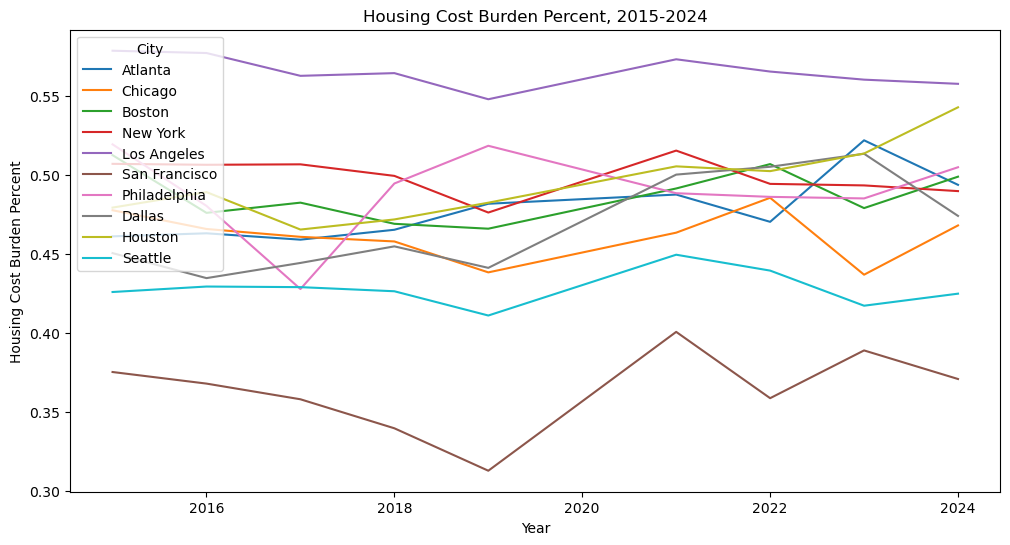

In [17]:
plt.figure(figsize = [12,6])
sns.lineplot(data=df_city_econ_data,x='year',y='housing_cost_burden_pct',hue='city')
plt.title('Housing Cost Burden Percent, 2015-2024')
plt.ylabel('Housing Cost Burden Percent')
plt.xlabel('Year')
plt.legend(title='City', loc='upper left')
plt.show()

In [18]:
df_city_econ_data['burden_rank_2024'] = (
   df_city_econ_data[df_city_econ_data['year']==2024]
    .groupby('city')['housing_cost_burden_pct']
    .rank(ascending=False, method='dense')
    .reindex(df_city_econ_data.index, method='ffill')
)

In [19]:
ranking_2024 = df_city_econ_data[df_city_econ_data['year']==2024][['city', 'housing_cost_burden_pct', 'burden_rank_2024']].sort_values('burden_rank_2024')
print(ranking_2024)

             city  housing_cost_burden_pct  burden_rank_2024
80    Los Angeles                 0.557845               1.0
81  San Francisco                 0.370826               1.0
82        Atlanta                 0.493848               1.0
83        Chicago                 0.468129               1.0
84         Boston                 0.499016               1.0
85       New York                 0.489874               1.0
86   Philadelphia                 0.505000               1.0
87         Dallas                 0.474164               1.0
88        Houston                 0.542964               1.0
89        Seattle                 0.424896               1.0


This analysis demonstrates a few interesting things. First, there are some counterintuitive outcomes. Second, overall change is very limited. Los Angeles comfortably maintained its position as least affordable from 2015-2024. San Francisco has similarly  

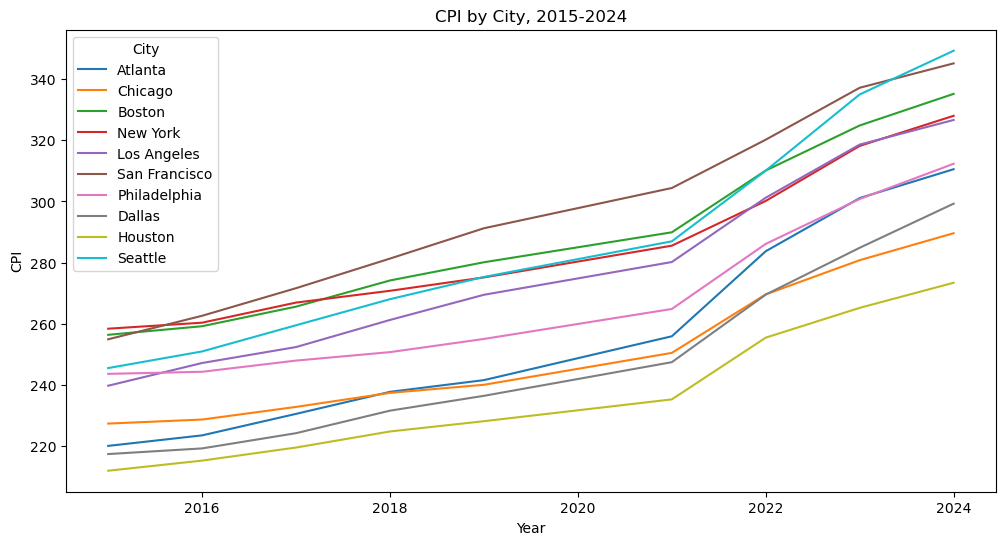

In [20]:
plt.figure(figsize = [12,6])
sns.lineplot(data=df_combined_data,x='year',y='cpi_index',hue='city')
plt.title('CPI by City, 2015-2024')
plt.ylabel('CPI')
plt.xlabel('Year')
plt.legend(title='City', loc='upper left')
plt.show()

# We are going to perform some GroupBys to help analyze housing affordability

In [21]:
# Find the 2015 CPI for each city to use as baseline (instead of using historical baseline of 100)
cpi_2015 = df_combined_data[df_combined_data['year'] == 2015][['city', 'cpi_index']].rename(columns={'cpi_index': 'cpi_base_2015'})

# Merge baseline into our main DF
df_combined_data = pd.merge(df_combined_data, cpi_2015, on='city', how='left')

# Calculate the 'Real' values in 2015 Dollars by dividing by CPI index and multiplying by baseline
df_combined_data['real_home_value'] = (df_combined_data['median_home_value'] / df_combined_data['cpi_index']) * df_combined_data['cpi_base_2015']
df_combined_data['real_income'] = (df_combined_data['median_household_income'] / df_combined_data['cpi_index']) * df_combined_data['cpi_base_2015']

## GroupBy #1: Long-Term Real vs. Nominal Housing Costs - This will compare average nominal home prices with "real" (CPI-adjusted) home prices for each city. This will show which cities have housing markets that are outpacing cost of living increases and highlight "real" home value.

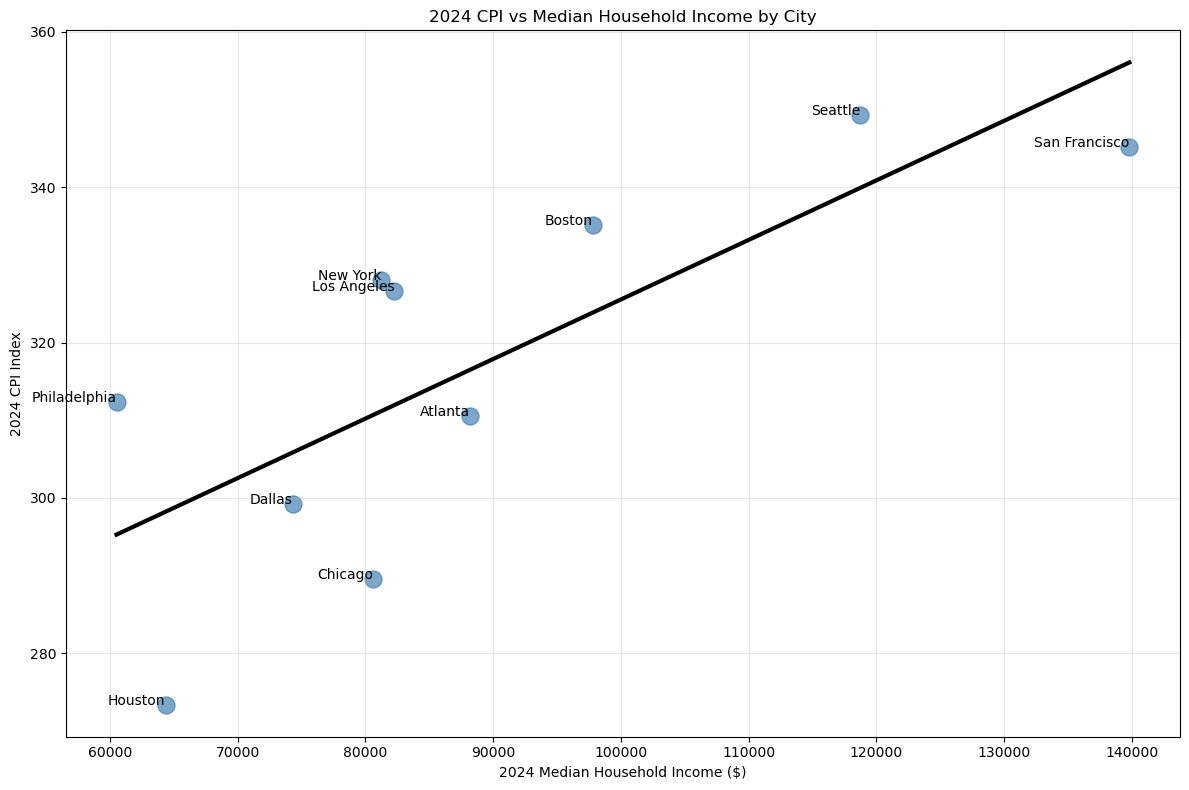

In [22]:
# Simple 2024 CPI vs Median Income scatter
df_2024 = df_combined_data[df_combined_data['year'] == 2024][['city', 'cpi_index', 'median_household_income']].copy()

plt.figure(figsize = [12, 8])
plt.scatter(df_2024['median_household_income'], df_2024['cpi_index'], s=150, color = 'steelblue', alpha=0.7)

m, b = np.polyfit(df_2024['median_household_income'], df_2024['cpi_index'], 1) 
x_line = np.linspace(df_2024['median_household_income'].min(), df_2024['median_household_income'].max(), 100)
plt.plot(x_line, m * x_line + b, color='black', linewidth=3, label=f'y = {m:.2f}x + {b:.2f}')


for i, row in df_2024.iterrows():
    plt.text(row['median_household_income'],
             row['cpi_index'],
             row['city'],
             fontsize=10, ha='right')

plt.xlabel('2024 Median Household Income ($)')
plt.ylabel('2024 CPI Index')
plt.title('2024 CPI vs Median Household Income by City')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [23]:
# Group by cities and display median home / real home value and CPI index
city_real_stats = df_combined_data.groupby('city')[['median_home_value', 'real_home_value', 'cpi_index']].mean().sort_values(by='real_home_value',ascending=False) # Sorted by highest real home value at top
print("1. City Baseline: Nominal vs. Real Home Values")
display(city_real_stats)

1. City Baseline: Nominal vs. Real Home Values


,median_home_value,real_home_value,cpi_index
city,,,
San Francisco,1.199500e+06,1.030511e+06,296.508556
Seattle,7.730111e+05,6.581355e+05,286.731000
Los Angeles,7.496111e+05,6.423671e+05,277.397000
New York,6.639000e+05,6.010384e+05,284.821778
Boston,6.087444e+05,5.386782e+05,288.382444
Atlanta,3.522778e+05,2.996088e+05,256.064778
Chicago,2.839778e+05,2.568600e+05,250.743333
Dallas,2.443667e+05,2.105487e+05,247.761667
Houston,2.168556e+05,1.917374e+05,236.540222


### The data shows that the U.S. housing affordability issue is a regional issue rather than a byproduct of national inflation. The "real" cost of homes in San Francisco, for example, remains far higher even after adjusting for local CPI / cost of living. For prospective buyers, geographic location is likely the most important factor that determines affordability.

## GroupBy #2: Purchasing Power - This will track "real" income and housing cost burden across cities by year. It will show if the average household's purchasing power is growing/shrinking or if inflation is eroding salaries.

In [24]:
# Grouping by year and displaying real income, housing cost burden percentage, and CPI index
city_purchasing_stats = df_combined_data.groupby('year')[['real_income', 'housing_cost_burden_pct', 'cpi_index']].mean().sort_values(by='year',ascending=False)
print("2a. Yearly Macro Trend: Real Income & Housing Burden")
display(city_purchasing_stats)

2a. Yearly Macro Trend: Real Income & Housing Burden


,real_income,housing_cost_burden_pct,cpi_index
year,,,
2024,66270.218825,0.482656,316.9403
2023,65832.884592,0.481073,306.6452
2022,67137.405666,0.481537,290.6163
2021,66242.344641,0.487640,270.0798
2019,66149.324956,0.457682,259.2411
2018,63023.610062,0.464418,253.7656
2017,61294.954526,0.459706,247.0992
2016,59751.433370,0.469085,241.1124
2015,57460.900000,0.478829,237.5183


### Real income grew steadily from 2015-2022; however, stagnated and slightly declined in 2023 and 2024. Housing cost burden increased slightly over the timeframe. It may be more helpful to break down the real income and housing cost burden growth by city.

In [25]:
# Create dataframes for just years 2015 and 2024 so we can complete our percent change calculation (2024 metrics - 2015 metrics) / 2015 metrics
df_2015 = df_combined_data[df_combined_data['year'] == 2015][['city', 'real_income', 'housing_cost_burden_pct']]

df_2024 = df_combined_data[df_combined_data['year'] == 2024][['city', 'real_income', 'housing_cost_burden_pct']]

# Merge the 2015 and 2024 data; add year suffixes to label the data
growth_comparison = pd.merge(df_2015, df_2024, on='city', suffixes=('_2015', '_2024'))

# Calculate percent changes
growth_comparison['income_growth_pct'] = ((growth_comparison['real_income_2024'] - growth_comparison['real_income_2015']) / growth_comparison['real_income_2015']) * 100
growth_comparison['burden_growth_pct'] = ((growth_comparison['housing_cost_burden_pct_2024'] - growth_comparison['housing_cost_burden_pct_2015']) / growth_comparison['housing_cost_burden_pct_2015']) * 100
growth_comparison['net_growth_gap'] = growth_comparison['income_growth_pct'] - growth_comparison['burden_growth_pct']

print("2b. City Growth Comparison")
display(growth_comparison[['city', 'income_growth_pct', 'burden_growth_pct', 'net_growth_gap']].sort_values(by='net_growth_gap', ascending=False))

2b. City Growth Comparison


,city,income_growth_pct,burden_growth_pct,net_growth_gap
2,Boston,28.383114,-2.659901,31.043015
1,Chicago,24.811765,-2.014210,26.825975
4,Los Angeles,16.049414,-3.623578,19.672991
3,New York,14.766646,-3.405795,18.172442
0,Atlanta,24.424489,7.077179,17.347311
6,Philadelphia,14.485876,-2.789899,17.275776
5,San Francisco,12.113182,-1.181025,13.294207
7,Dallas,17.566158,5.230998,12.335160
9,Seattle,3.871310,-0.246927,4.118237
8,Houston,3.797909,13.254951,-9.457042


### All cities saw an increase in income from 2015-2024 of varying degrees. The Net Growth Gap is the income growth percentage less burden growth percentage. The Net Growth Gap ranks cities and shows where real wage gains are outpacing the rising risk of housing instability. This data paints a different picture than purely examining housing cost burden percentage, and shows that some cities with high HCB percentages (LA, NY, BOS) are trending in the right direction and households are becoming less vulnerable, whereas traditionally more affordable cities like Houston are trending in the wrong direction.

## GroupBy #3: CPI vs. Unemployment - This will help explain why some cities survive higher prices better than others and if expensive cities are supported by more resilient labor markets. A city with a high CPI and low unemployment would be considered more resilient than a city with high costs and rising unemployment

In [26]:
# Calculate unemployment rate and misery index
df_combined_data['unemployment_rate'] = (df_combined_data['unemployment_count'] / df_combined_data['total_population']) * 100
df_combined_data['misery_index'] = df_combined_data['unemployment_rate'] + df_combined_data['cpi_index']

# Group by cities, display mean/min/max for CPI and unemployment rate, only display misery index mean
city_cpi_vs_unemployment = df_combined_data.groupby('city').agg({'cpi_index': ['mean', 'min', 'max'],'unemployment_rate': ['mean', 'min', 'max'],'misery_index': ['mean']
}).sort_values(by=('cpi_index', 'mean'), ascending=False)

print("3. City CPI vs. Unemployment")
display(city_cpi_vs_unemployment)


3. City CPI vs. Unemployment


cpi_index                   unemployment_rate            \
                     mean      min      max              mean       min   
city                                                                      
San Francisco  296.508556  254.910  345.151          2.982322  2.229858   
Boston         288.382444  256.376  335.178          3.620581  2.586743   
Seattle        286.731000  245.496  349.288          2.774212  2.159310   
New York       284.821778  258.376  328.006          3.622283  2.687632   
Los Angeles    277.397000  239.724  326.640          3.793552  2.886291   
Philadelphia   267.291667  243.609  312.322          4.179386  3.125643   
Atlanta        256.064778  220.048  310.540          3.295566  2.723143   
Chicago        250.743333  227.343  289.605          4.327764  3.442480   
Dallas         247.761667  217.375  299.273          2.551934  2.202527   
Houston        236.540222  211.926  273.400          3.293442  2.775124   

                        misery_index  
                    max         mean  
city                                  
San Francisco  5.028330   299.490877  
Boston         4.785711   292.003026  
Seattle        3.447282   289.505212  
New York       5.985406   288.444061  
Los Angeles    5.804423   281.190552  
Philadelphia   5.315524   271.471052  
Atlanta        4.029965   259.360343  
Chicago        5.571763   255.071097  
Dallas         3.230649   250.313601  
Houston        4.466939   239.833664

### There is a significant gap in daily costs between the highest cost of living city (SF) and lowest cost of living city (Houston), but only a slight difference in unemployment rates across cities. The "Misery Index" calculates CPI + Unemployment rate and is a metric used to measure economic distress felt by the average household. In our case, most of the "Misery" in the "Misery Index" comes from the CPI, and even though SF/BOS/SEA have lower unemployment compared to other cities (NY, LA, PHI, CHI), households in SF/BOS/SEA see higher levels of economic distress according to this metric.

## GroupBy #4: Direct Affordability - This will determine how many years of total household income it takes to buy a home. This will create a standardized affordability score that allows us to compare high-wage and low-wage cities directly

In [27]:
df_combined_data['real_value_to_income'] = df_combined_data['real_home_value'] / df_combined_data['real_income']

real_value_to_income = df_combined_data.groupby('city')['real_value_to_income'].agg(['mean', 'min', 'max']).sort_values(by='mean', ascending=False)

print("4. Real Value-to-Income Ratio")
display(real_value_to_income)

4. Real Value-to-Income Ratio


,mean,min,max
city,,,
Los Angeles,11.091176,10.341452,11.869705
San Francisco,10.123883,9.404082,10.723491
New York,9.815250,9.585365,10.111444
Boston,7.855266,7.258772,8.320825
Seattle,7.593119,6.607425,8.110739
Atlanta,5.052073,4.624684,5.393282
Chicago,4.506883,4.232568,4.745099
Dallas,4.155863,3.318960,4.899083
Philadelphia,3.967447,3.636482,4.209353


### Cities at the top of this list (LA,SF,NY) see a large affordability issue, where the median home costs 10-11 years of total household income, ~2-3 times as long as residents in ATL, CHI, DAL, PHI, HOU. The "max" column highlights that even more "affordable" markets like DAL, PHI, HOU are becoming increasingly unaffordable

In [28]:
# Setting up criteria for affordability categories
def affordability_categories(ratio):
    if ratio >= 8.0:
        return 'Severe'
    elif ratio >= 5.0:
        return 'Strained'
    else:
        return 'Sustainable'

# Apply the function to categorize cities by status
real_value_to_income['market_status'] = real_value_to_income['mean'].apply(affordability_categories)

print("Housing Affordability Categorization:")
display(real_value_to_income[['mean', 'market_status']])

Housing Affordability Categorization:


,mean,market_status
city,,
Los Angeles,11.091176,Severe
San Francisco,10.123883,Severe
New York,9.815250,Severe
Boston,7.855266,Strained
Seattle,7.593119,Strained
Atlanta,5.052073,Strained
Chicago,4.506883,Sustainable
Dallas,4.155863,Sustainable
Philadelphia,3.967447,Sustainable


### The above table displays the Real House Value to Income Ratio categorized by status. Traditionally, a ratio of 3.0 is affordable and a ratio of 7.0+ shows a major housing affordability issue.

## Using the information from our GroupBys, we would like to now read and merge 3 additional affordability metrics from our SQL queries in Snowflake to aggregate by-city data to get a report of each city's performance over the 10-year period and create an overall weighted score to show which cities are the most / least affordable

In [29]:
# Income to rent measures the number of months of rent covered by the mean household salary; .csv output from Snowflake query
df_income_to_rent = pd.read_csv('income_to_rent.csv')

df_cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       90 non-null     str    
 1   year       90 non-null     int64  
 2   cpi_index  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


In [30]:
# Income to rent measures the difference between average annual rent growth percentage and average annual income growth percentage; .csv output from Snowflake query
df_growth_gap = pd.read_csv('rent_to_nomincome.csv')

df_cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       90 non-null     str    
 1   year       90 non-null     int64  
 2   cpi_index  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


In [31]:
# Education affordability ranks cities by affordability metric that is weighted by educational level. Affordability (Median Income / Median Gross Rent) * AVG Bachelors %; .csv output from Snowflake query
df_edu_score = pd.read_csv('education_affordability.csv')

df_cpi.info()

<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   city       90 non-null     str    
 1   year       90 non-null     int64  
 2   cpi_index  90 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 3.0 KB


In [32]:
# Define the weights (importance) for each Groupby
w_home_value = .15 # metric from Python groupby
w_purchase_power = .15 # metric from Python groupby
w_misery = .1 # metric from Python groupby
w_income_growth = .15 # metric from Python groupby
w_income_to_rent = .15 # metric from SQL query
w_rent_to_nomincome = .15 # metric from SQL query
w_education_affordability = .15 # metric from SQL query

# Aggregate to get mean for static metrics and calculate growth for others.
city_rank_data = df_combined_data.groupby('city').agg({
    'real_home_value': 'mean',
    'real_value_to_income': 'mean',
    'misery_index': 'mean',
    'real_income': lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] 
}).rename(columns={'real_income': 'income_growth_pct'})

city_rank_data = city_rank_data.merge(df_income_to_rent[['city', 'months_income_covers_rent']], on='city', how='left')
city_rank_data = city_rank_data.merge(df_growth_gap[['city', 'annual_rent_income_gap_pct']], on='city', how='left')
city_rank_data = city_rank_data.merge(df_edu_score[['city', 'education_affordability_score']], on='city', how='left')

# For these four metrics, lower is better (we want low ratios, low housing cost burden, low misery index, and small gap between rent growth and income growth)
city_rank_data['home_value_rank'] = city_rank_data['real_home_value'].rank(ascending=True)
city_rank_data['purchase_power_rank'] = city_rank_data['real_value_to_income'].rank(ascending=True)
city_rank_data['misery_rank'] = city_rank_data['misery_index'].rank(ascending=True)
city_rank_data['growth_gap_rank'] = city_rank_data['annual_rent_income_gap_pct'].rank(ascending=True)

# For income growth, months of rent covered by income, and educations scores, higher is better 
city_rank_data['income_growth_rank'] = city_rank_data['income_growth_pct'].rank(ascending=False)
city_rank_data['rent_coverage_rank'] = city_rank_data['months_income_covers_rent'].rank(ascending=False)
city_rank_data['edu_score_rank'] = city_rank_data['education_affordability_score'].rank(ascending=False)

# Apply the weights to our rankings
city_rank_data['weighted_score'] = (city_rank_data['home_value_rank'] * w_home_value) + (city_rank_data['purchase_power_rank'] * w_purchase_power)  + (city_rank_data['misery_rank'] * w_misery) + (city_rank_data['income_growth_rank'] * w_income_growth) + (city_rank_data['rent_coverage_rank'] * w_income_to_rent)  + (city_rank_data['growth_gap_rank'] * w_rent_to_nomincome) + (city_rank_data['edu_score_rank'] * w_education_affordability)

# Output final leaderboard
final_leaderboard = city_rank_data.sort_values(by='weighted_score')
print("Weighted Score of City Affordability")
display(final_leaderboard[['city','weighted_score','purchase_power_rank','income_growth_rank','home_value_rank','misery_rank','rent_coverage_rank', 'growth_gap_rank', 'edu_score_rank']])

final_leaderboard.to_excel("final_leaderboard.xlsx")

Weighted Score of City Affordability


,city,weighted_score,purchase_power_rank,income_growth_rank,home_value_rank,misery_rank,rent_coverage_rank,growth_gap_rank,edu_score_rank
2,Chicago,3.150,4.0,2.0,4.0,3.0,3.0,1.0,5.0
0,Atlanta,4.300,5.0,3.0,5.0,4.0,4.0,6.0,3.0
3,Dallas,4.925,3.0,4.0,3.0,2.0,5.5,9.0,7.0
1,Boston,5.025,7.0,1.0,6.0,9.0,7.5,2.0,4.0
9,Seattle,5.300,6.0,9.0,9.0,8.0,1.0,4.0,1.0
4,Houston,5.575,1.0,10.0,2.0,1.0,5.5,10.0,8.0
7,Philadelphia,6.050,2.0,7.0,1.0,5.0,9.0,8.0,10.0
6,New York,6.325,8.0,6.0,7.0,7.0,7.5,3.0,6.0
8,San Francisco,6.700,9.0,8.0,10.0,10.0,2.0,7.0,2.0
5,Los Angeles,7.650,10.0,5.0,8.0,6.0,10.0,5.0,9.0


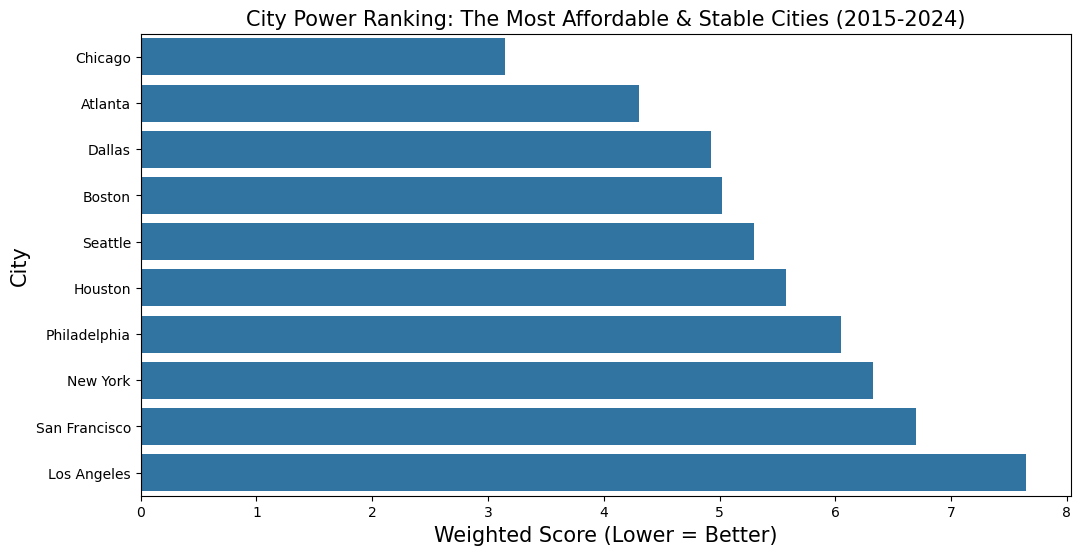

In [33]:
scoreboard_plot = final_leaderboard.reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x='weighted_score', 
    y='city', 
    data=scoreboard_plot)

plt.title('City Power Ranking: The Most Affordable & Stable Cities (2015-2024)', fontsize=15)
plt.xlabel('Weighted Score (Lower = Better)',fontsize=15)
plt.ylabel('City',fontsize=15)

plt.savefig("scoreboard_plot.png", dpi=300)


## This table weights all of the metrics and findings from our 4 Python GroupBys and selected 3 outputs from SQL queries to determine a weighted score for each city to determine overall affordability. In these cases, home value measures "cheap" versus "expensive" houses in real home value, purchase power measures salaries compared to house prices, income growth demonstrates whether the local economy is growing or stagnnt, and misery index measures higher inflation and economic stress. From SQL query output, months income covers rent adds in a safety margin to rental prices based on income, annual rent/income gap measures stability, and educaton affordability score shows where education provides a buffer against high costs.

## According to these weighted scores, Chicago, Atlanta, and Dallas are the 3 most affordable cities, while Los Angeles, Seattle, and New York are the three least affordable

# STEP 4: Modeling: We will now move from describing what the data shows from 2015-2024 regarding affordability and attempt to model what will happen moving forward

## Model #1: Affordability Forecast Linear Regression

### We will use a linear regression to forecast a housing price-to-income ratio (PIR) (calculating the number of years of houshold income required to purchase a house). This will allow the financial stress in different housing markets and fluctuations in borrowing cots.

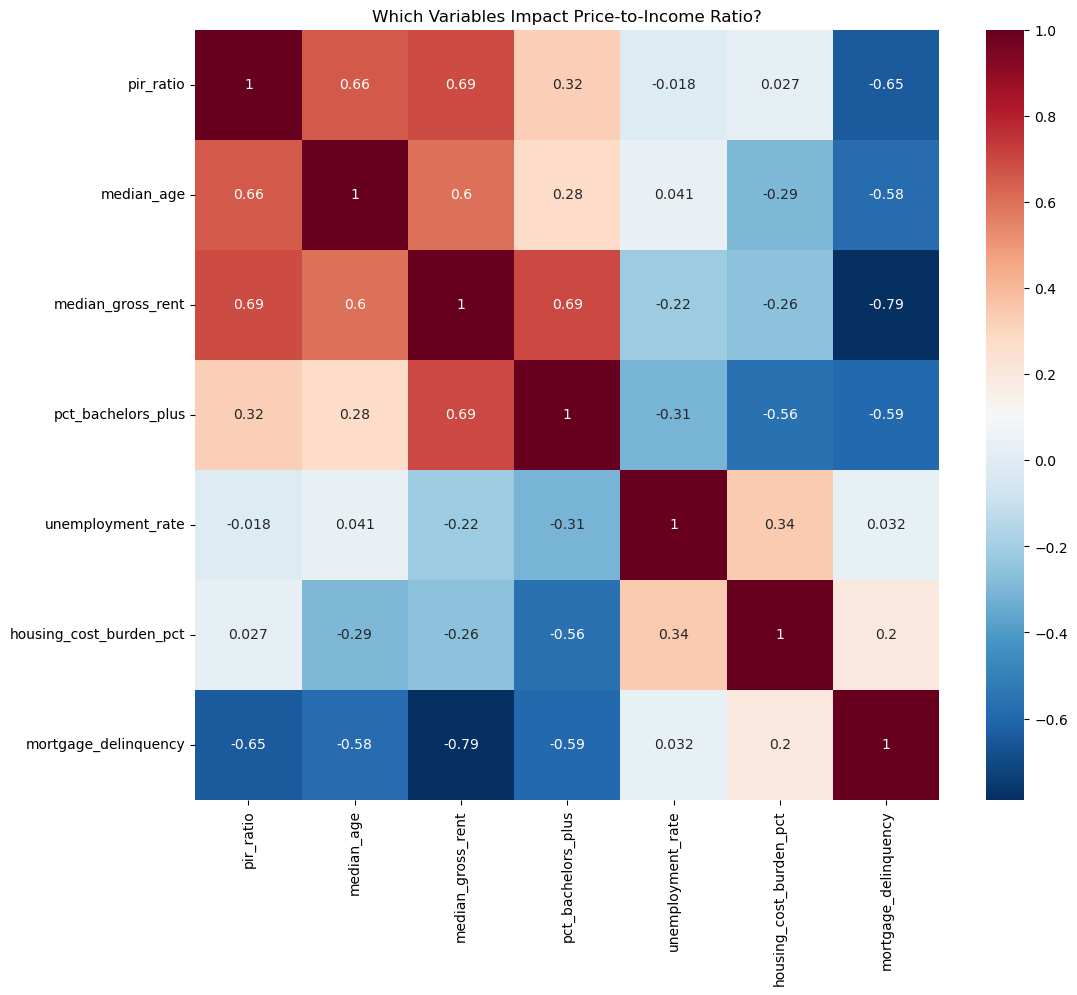

In [34]:
# Create our PIR ratio by dividing real home value by real income
df_combined_data['pir_ratio'] = df_combined_data['real_home_value'] / df_combined_data['real_income']

# PIR ratio will be our dependent variable, others listed are independent variables
corr_features = ['pir_ratio', 
    'median_age', 
    'median_gross_rent', 
    'pct_bachelors_plus', 
    'unemployment_rate', 
    'housing_cost_burden_pct',
    'mortgage_delinquency'
]

corr_matrix = df_combined_data[corr_features].corr()

# 3. Plot heatmap of variables
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r')

plt.title('Which Variables Impact Price-to-Income Ratio?')
plt.show()

### Variables having strong correlation with PIR include: Median Age, Median Gross Rent, % Bachelors Plus, and Mortgage Delinquency

In [35]:
# Create a copy of our dataframe to serve as our linear regression dataframe
df_linear_model = df_combined_data.copy()

#Convert the % Bachelors plus metric from a decimal to whole percentage
df_linear_model['pct_bachelors_plus'] = df_linear_model['pct_bachelors_plus'] * 100

# Create the X / Y columns
X1 = df_linear_model[['median_age','median_gross_rent','pct_bachelors_plus','mortgage_delinquency']]
y1 = df_linear_model['pir_ratio']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.5, random_state=7)

linreg_model = LinearRegression()
linreg_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
print("X train = ", X_train.shape)
print("y train = ", y_train.shape)
print("\nX test = ", X_test.shape)
print("y test = ", y_test.shape)

X train =  (45, 4)
y train =  (45,)

X test =  (45, 4)
y test =  (45,)


In [37]:
linreg_model.coef_

array([ 0.28684691,  0.00437148, -0.05213658, -0.37209139])

In [38]:
linreg_model.intercept_

np.float64(-6.894435660573728)

In [39]:
linreg_model.predict([[0,0,0,0]])

/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([-6.89443566])

In [40]:
X1['intercept']= 1 

In [41]:
linreg_model = sm.OLS(y1, X1)

results = linreg_model.fit()

In [42]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              pir_ratio   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.585
Method:                 Least Squares   F-statistic:                     32.43
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           2.10e-16
Time:                        22:43:55   Log-Likelihood:                -175.80
No. Observations:                  90   AIC:                             361.6
Df Residuals:                      85   BIC:                             374.1
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
median_age               0.3785      0.119      3.187      0.002       0.142       0.615
median_gross_rent        0.0037      0.001      3.772      0.000       0.002       0.006
pct_bachelors_plus      -0.0550      0.023     -2.400      0.019      -0.101      -0.009
mortgage_delinquency    -0.7772      0.409     -1.899      0.061      -1.591       0.036
intercept               -8.2696      4.446     -1.860      0.066     -17.109       0.569
==============================================================================
Omnibus:                        4.750   Durbin-Watson:                   1.234
Prob(Omnibus):                  0.093   Jarque-Bera (JB):                2.995
Skew:                           0.259   Prob(JB):                        0.224
Kurtosis:                       2.272   Cond. No.                     3.64e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.64e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
model_rmse = LinearRegression()

model_rmse.fit(X_train, y_train)

y_predicted = model_rmse.predict(X_test)

rmse = sqrt(mean_squared_error(y_test, y_predicted))

print("RMSE = ", f'{rmse:.2f}')

RMSE =  1.75


## The output of our linear regression model using housing and demographic variables to predict Home Price-to-Income Ratio is:

## Coefficients: 

## Median Age (0.38): For every one-year increase in the median age of a city, the price-to-income ratio increases by 0.38. This suggests that "older" cities tend to be less affordable.

## Median Gross Rent (0.004): For every one-dollar increase in monthly rent, the home price-to-income ratio rises by 0.004. (Alternatively: a $250 rent hike adds 1 full point to the PIR).

## % Bachelors+ (-0.055): For every 1% increase in residents with a bachelor's degree, the PIR decreases by 0.05. (Note: I used the scaled version -0.052 assuming you fixed the decimal issue). This suggests that higher education levels correlate with better affordability, likely because incomes rise faster than home prices in these areas.

## Mortgage Delinquency (-0.772): For every 1% increase in mortgage delinquency, the PIR decreases by 0.37. This indicates that economic distress or higher risk in a market generally suppresses home price premiums.

## R-squared value is .604, this means that our independent variables explain ~81% of the variance in Real Home prices

## RMSE: On average, our model's prediction is 1.75 years of income required to purchase a house in each city. The average city in our data has a ratio of 6.81

# Model #2: Logistic Regression

In [44]:
df_logistic_model = df_combined_data.copy()

# We will consider 6.0 the cutoff for "High Housing Burden"
df_logistic_model['is_high_burden'] = (df_logistic_model['pir_ratio'] > 6.0).astype(int)

X_logistic = df_logistic_model[['median_gross_rent','median_age','pct_bachelors_plus', 'mortgage_delinquency']]
y_logistic = df_logistic_model['is_high_burden']

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X_logistic, y_logistic, test_size=0.5, random_state=7)

In [46]:
print("X train = ", X_train.shape)
print("y train = ", y_train.shape)
print("\nX test = ", X_test.shape)
print("y test = ", y_test.shape)

X train =  (45, 4)
y train =  (45,)

X test =  (45, 4)
y test =  (45,)


In [47]:
plot_df = X_train.copy()
plot_df['is_high_burden'] = y_train

plot_df['burden_status'] = plot_df['is_high_burden'].apply(lambda x: 'High Burden' if x else 'Affordable')
plot_df.head()

,median_gross_rent,median_age,pct_bachelors_plus,mortgage_delinquency,is_high_burden,burden_status
1,985,34.2,0.366433,1.975,0,Affordable
69,1877,35.9,0.673005,0.450,1,High Burden
78,1362,34.5,0.370635,2.233,0,Affordable
3,1317,36.0,0.368444,2.183,1,High Burden
35,1443,36.9,0.389843,1.917,1,High Burden


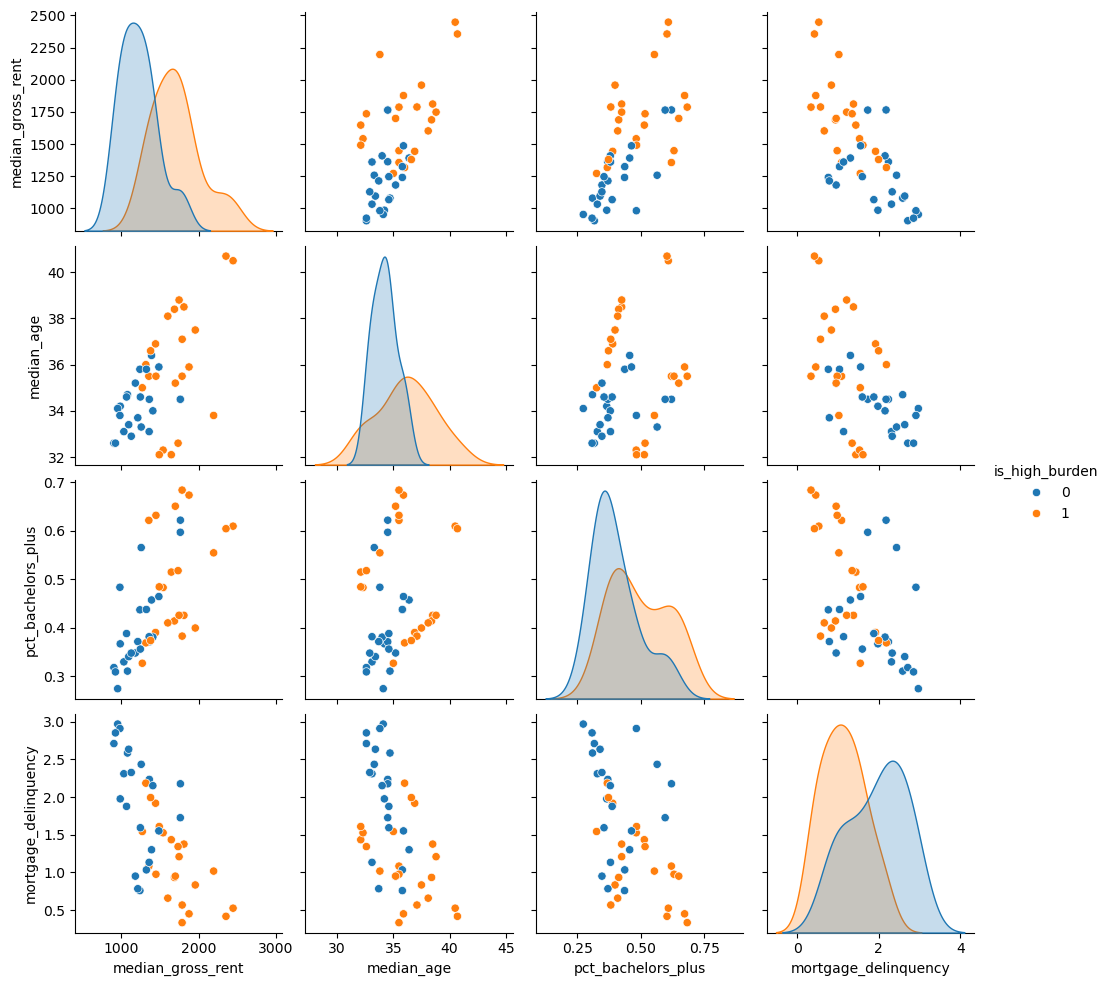

In [48]:
sns.pairplot(plot_df, hue='is_high_burden')

<Axes: xlabel='median_gross_rent', ylabel='burden_status'>

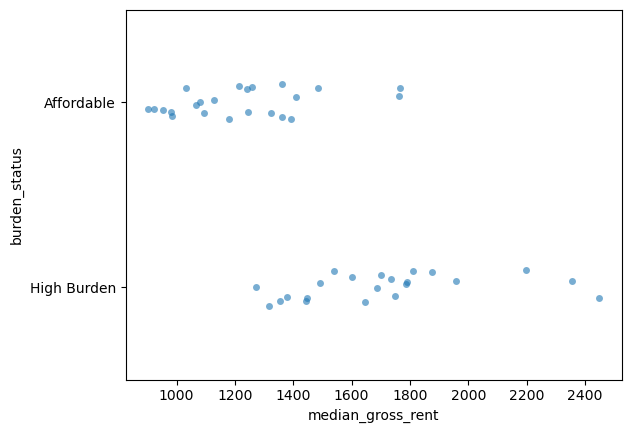

In [49]:
sns.stripplot(x='median_gross_rent', y='burden_status', jitter=True, 
              data=plot_df, alpha=0.6)

<Axes: xlabel='median_age', ylabel='burden_status'>

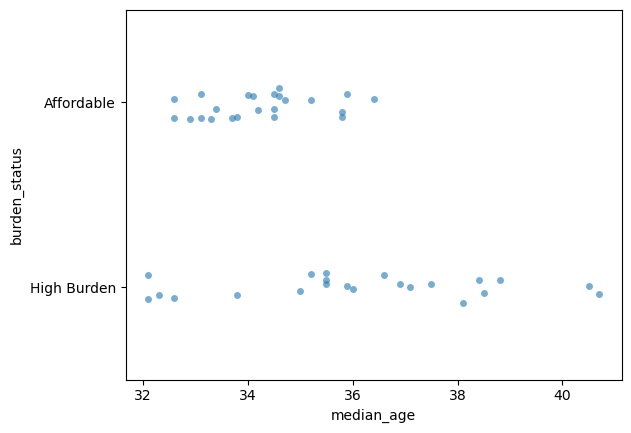

In [50]:
sns.stripplot(x='median_age', y='burden_status', jitter=True, 
              data=plot_df, alpha=0.6)

<Axes: xlabel='pct_bachelors_plus', ylabel='burden_status'>

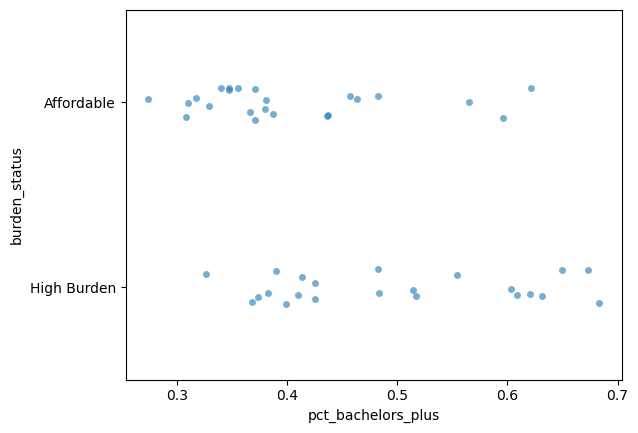

In [51]:
sns.stripplot(x='pct_bachelors_plus', y='burden_status', jitter=True, 
              data=plot_df, alpha=0.6)

<Axes: xlabel='mortgage_delinquency', ylabel='burden_status'>

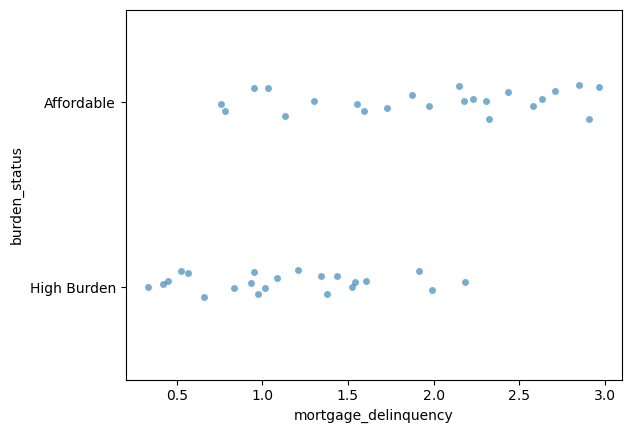

In [52]:
sns.stripplot(x='mortgage_delinquency', y='burden_status', jitter=True, 
              data=plot_df, alpha=0.6)

## Based on the pair plot and strip plots, it appears that median gross rent will be the only optimal variable we can use to determine if a city will be high burden or affordable due to clustering of observations on all other plots; at this point, a multiple regression does not seem ideal. We will assume that this could be due to a limited # of observations (only 10 cities) and will continue running the multiple regression model.

In [53]:
log_reg = LogisticRegression() #solver= 'liblinear', C=1000)
log_reg.fit(X_train[['median_gross_rent']], y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [54]:
log_reg.score(X_test[['median_gross_rent']], y_test)

0.8

In [55]:
input_gross_rent = plot_df[['median_gross_rent']].values
print(input_gross_rent[0:10])

[[ 985]
 [1877]
 [1362]
 [1317]
 [1443]
 [2448]
 [1811]
 [1079]
 [1271]
 [1032]]


In [56]:
burden_status_prediction = log_reg.predict(input_gross_rent)
burden_status_prediction[0:10]

/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0, 1, 0, 0, 1, 1, 1, 0, 0, 0])

In [57]:
burden_mask = (plot_df['burden_status'] == 'High Burden').values

print(burden_mask[0:10])

[False  True False  True  True  True  True False  True False]


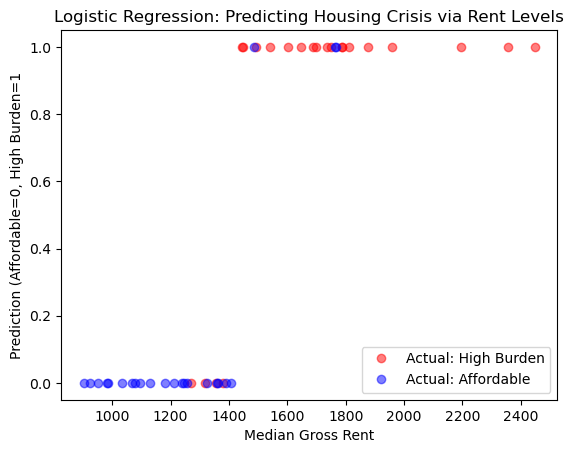

In [58]:
plt.plot(input_gross_rent[burden_mask], burden_status_prediction[burden_mask], 'ro', label='Actual: High Burden', alpha=0.5)
plt.plot(input_gross_rent[~burden_mask], burden_status_prediction[~burden_mask], 'bo', label='Actual: Affordable', alpha=0.5)

plt.xlabel('Median Gross Rent')
plt.ylabel('Prediction (Affordable=0, High Burden=1')
plt.title('Logistic Regression: Predicting Housing Crisis via Rent Levels')
plt.legend();

plt.savefig("logistic_regression_output.png", dpi=300)

/opt/conda/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


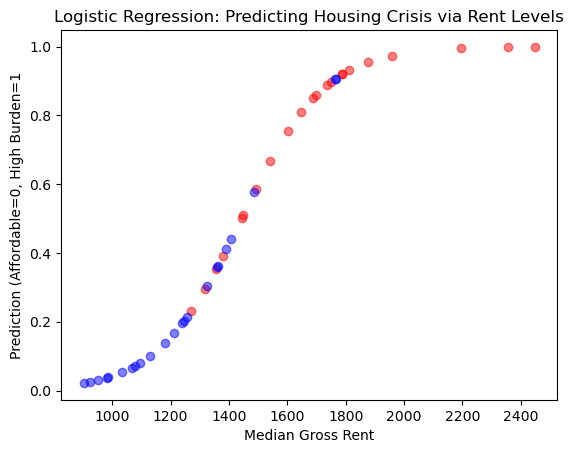

In [59]:
prob_prediction = log_reg.predict_proba(input_gross_rent)[:, 1]

plt.plot(input_gross_rent[burden_mask], prob_prediction[burden_mask], 'ro', label='Actual: High Burden',alpha=0.5)
plt.plot(input_gross_rent[~burden_mask], prob_prediction[~burden_mask], 'bo', label='Actual: Affordable',alpha=0.5)

plt.xlabel('Median Gross Rent')
plt.ylabel('Prediction (Affordable=0, High Burden=1')
plt.title('Logistic Regression: Predicting Housing Crisis via Rent Levels');

plt.savefig("prob_prediction.png", dpi=300)


In [60]:
confusion_matrix(y_train, burden_status_prediction)

array([[20,  3],
       [ 4, 18]])

In [61]:
conf_m = pd.DataFrame(confusion_matrix(y_train, burden_status_prediction))
conf_m.index = ['Actual: Affordable (0)', 'Actual: High Burden (1)']
conf_m.columns = ['Predicted: Affordable (0)', 'Predicted: High Burden (1)']
conf_m

,Predicted: Affordable (0),Predicted: High Burden (1)
Actual: Affordable (0),20,3
Actual: High Burden (1),4,18


## Logistic regression output calculates the probability that a city will enter a high-burden state. Our model achieved an accuracy of 80% using median gross rent, median age, pct bachelors plus, and morgage delinquency. Our confusion matrix shows that the model accurately identified 20 affordable and 18 high-burden cities. It was reliable; however, did produce 3 false positives and 4 false negatives. We believe that having a larger pool of data in the form of far greater than 10 cities (with 10 years worth of data) would provide better training and testing data for our model. This would be a recommendation for a next step of our project

# STEP 5: Conclusion

## Our analysis synthesizes traditional housing metrics with demographic and economic indicators to create a view of American urban affordability. By blending Python analysis and SQL insights, we reach the following conclusions:

## Weighted Scoring Leaderboard:

### Our final weighted scoring system used seven distinct metrics: Home Value, Purchase Power, Income Growth, Misery Index, Rental Safety Margins, Stability Gaps, and Education Buffers.

### Winners and Losers: 

### Most Affordable (Chicago, Atlanta, Dallas): Chicago takes #1 by being the only city with no weak rankings, specifically leading in Growth Gap and Income Growth

### Least Affordable (Los Angeles, New York, San Francisco): Los Angeles ranks last due to a "triple threat" of worst-in-class Purchase Power, Rent Coverage, and low Education Scores.

### Overall Comparisons: 

### "Cheap" is not optimal: Philadelphia and Houston have the lowest home prices but rank in the bottom half overall. This proves that "cheap" housing doesn't equal affordability if Rent Coverage and Education are low.

### Importance of education: Education rate is a good proxy for income and income growth. For example, Seattle has the second-most expensive housing but remains in the middle of the pack because it ranks #1 in Education and #1 in Rent Coverage, allowing residents to absorb higher costs

### Bottom Line: Affordability is driven by more than just housing prices. A city's overall affordability is more defined by 1) the gap between how fast incomes grow and rents rise, and 2) "fragile" cities like LA and Philadelphia have no buffer, meaning even a small spike in mortgage rates or inflation can push large segments of the population into a "high burden" state. These cities do not have the built-in buffer provided by high income growth and rent coverage.

## Linear Regression:

### Although this final output of our linear regression model only achieved an R-Squared value of .604, it achieved the lowest RMSE of 1.75 years of income relative to a dataset average PIR of 6.81. Significant next steps would include greatly increasing the datapoints for model training and testing, which would be accomplished by increasing the number of cities measured to greater than 10. We could expand analysis and look at the 100 largest U.S. cities to increase our dataset.

## Logistic Regression: 

### To assess the probability of a city entering a "high-burden" state (high-burden specifically referencing housing cost burden percentage), our logistic regression model acieved an 80% accuracy rate. The model accurately identified 20 affordable, and 18 high-burden cities while producing 3 false positives and 4 false negatives. This highlights that rent prices are a good preducitor of housing burden. The current scope of our model is again limited by the sample size of 10 cities over 10 years. To improe training and testing, the next step for our research is to expand the dataset to include a large pool of cities. 